# Projet 01 - SQL : Interroger une base de réservations de vols

Bienvenue dans le premier projet du cahier de vacances Machine Learnia !

<div align="center">
<img src="./image.png" alt="ouvrir dans VSCode pour voir l'image" width="800"/>
</div>

Enfin nous y sommes ! Les Grandes Vacances ! :)

Tu viens de finir ta dernière journée de travail, et direction l'aéroport Paris-Charles de Gaulle ! Il fait 32 degrés, tu as ta valise à la main et ton vol pour Athènes est dans 3 heures. En attendant, autant pratiquer un peu de SQL (Pour réussir, il faut toujours pratiquer !)

Le but de ce TP est de te glisser dans la peau d'un analyste qui travaille pour l'aéroport. Sous tes yeux, le système de réservations : des passagers, des vols, des réservations. Ta mission sera de poser des questions à ces données et d'en tirer des réponses précises :

- Quels vols décollent de Nice cette semaine ?
- Quelles destinations rapportent le plus d'argent ?
- Qui embarque sur le vol de New York ?

À la fin du projet, tu sauras transformer n'importe quelle question de ce genre en une requête qui te donne la réponse en quelques millisecondes. Et bonne nouvelle, pas besoin d'être développeur ici pour y arriver : on part de zéro et chaque exercice vérifie tout seul que ta réponse est la bonne.

### L'outil du jour : SQL

Aujourd'hui, nous sommes entourés de bases de données relationnelles : elles font tourner les sites web, les applications mobiles, les banques, les systèmes de gestion et bien sûr les compagnies aériennes. À chaque fois que tu réserves un billet d'avion, une base de données enregistre quelque part qui tu es, quel vol tu prends et quel siège tu occupes.

SQL (Structured Query Language) est le langage standard pour dialoguer avec ces bases : on écrit une question dans un format précis, qu'on appelle une requête, et la base nous renvoie la réponse. Pour un Data Analyst, un Data Engineer ou toute autre personne travaillant avec de la data, c'est sans doute l'outil le plus utilisé au quotidien, et il n'a presque pas changé depuis 50 ans. Un excellent investissement, donc, et c'est pourquoi le premier projet de ce cahier de vacances porte sur SQL !

Ici on utilisera SQLite, une version légère qui tient dans un simple fichier (ou même dans la mémoire de l'ordinateur), parfaite pour apprendre. Rien de très exotique comme technologie, mais les concepts sont exactement les mêmes que sur PostgreSQL ou MySQL, les moteurs qu'on retrouve en entreprise.

Au programme : les requêtes de base, les agrégations, les jointures et les sous-requêtes. Autrement dit, les briques qu'on utilise vraiment tous les jours dans les métiers de la data.

# Avant tout : Import de nos librairies

Avant d'écrire la moindre requête, faisons le point sur notre installation. Si tu as suivi le tutoriel du README du repo, tu disposes déjà d'un environnement Python prêt à l'emploi (le dossier `.venv` créé avec `uv`). Un environnement, c'est une bulle isolée qui contient une version de Python et les librairies propres au projet, sans rien toucher au reste de ton ordinateur.

Dans ce projet, on va utiliser deux librairies :

- `sqlite3` : c'est elle qui nous permet de créer notre base de données SQLite et de lui envoyer des requêtes depuis Python. Bonne nouvelle, elle est incluse de base dans Python, il n'y a rien à installer.
- `pandas` : la librairie de référence pour manipuler des données en Python. On s'en servira pour afficher les résultats de nos requêtes sous forme de tableaux bien lisibles (des DataFrames). Elle n'est pas présente de base dans Python, il faut donc l'ajouter à notre environnement.

Pour ajouter `pandas` à l'environnement, ouvre un terminal à la racine du projet et tape :

```shell
uv add pandas
```

> **Important** : pour pouvoir utiliser les notebooks Jupyter il faudra installer la librairie `ipykernel` dans ton environnement. Si tu ne l'as pas encore fait, tape la commande suivante dans le terminal à la racine du projet :
> ```shell
> uv add ipykernel
> ```



Ensuite, une fois dans le notebook, il ne reste qu'à sélectionner le kernel de notre environnement : en haut à droite de l'éditeur, clique sur "Select Kernel" (ou "Sélectionner le noyau") et choisis l'environnement Python du projet, celui qui mentionne `.venv`. C'est lui qui contient le `pandas` qu'on vient d'installer. On peut maintenant lancer nos imports :

In [1]:
import sqlite3
import pandas as pd

# Partie 1 Création de la base de données

Avant de pouvoir interroger quoi que ce soit, il nous faut... des données ! Dans la vraie vie, la base de réservations existe déjà : c'est le système de la compagnie aérienne qui la remplit à chaque billet vendu. Ici, on va la fabriquer nous-mêmes, en miniature : 15 passagers, 15 vols et une vingtaine de réservations. C'est l'occasion parfaite pour découvrir comment une base de données se construit, avant d'apprendre à l'interroger.

Si vous n'êtes pas familier avec le langage SQL, je vous invite à consulter ce cours en ligne gratuit et assez simple. Il vous aidera à faire vos premiers pas et à réaliser la mission de ce projet.

https://www.w3schools.com/sql/sql_intro.asp


Notre base contient trois tables :

```txt
passengers (id, first_name, last_name, email, nationality)
flights    (id, flight_number, origin, destination, departure_time, arrival_time, aircraft, capacity, price_eur)
bookings   (id, passenger_id, flight_id, booking_date, seat_class, seat_number, status)
```

<div align="center">
<img src="./base_de_données.png" alt="ouvrir dans VSCode pour voir l'image" width="800"/>
</div>

La table `bookings` fait le lien entre les deux autres : chaque réservation pointe vers un passager (`passenger_id`) et vers un vol (`flight_id`). C'est exactement ça, une base relationnelle : des tables reliées entre elles par des identifiants.

On commence par ouvrir une connexion vers une base SQLite en mémoire. "En mémoire" signifie que la base vit dans la RAM le temps de la session : aucun fichier n'est créé, et la base est recréée à chaque exécution du notebook. C'est voulu, ça évite les surprises si tu relances les cellules dans le désordre.

In [2]:
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

print("Connexion à la base établie !")

Connexion à la base établie !


### Table 1 : les passagers

On crée la première table ensemble, et on en profite pour décortiquer la syntaxe de `CREATE TABLE`. Chaque ligne déclare une colonne avec son nom, son type, et éventuellement une contrainte :

- `id INTEGER PRIMARY KEY` : un entier qui identifie chaque passager de façon unique. C'est la clé primaire, celle vers laquelle les autres tables pourront pointer.
- `first_name TEXT NOT NULL` et `last_name TEXT NOT NULL` : du texte, avec la contrainte `NOT NULL` qui interdit d'enregistrer un passager sans prénom ou sans nom.
- `email TEXT UNIQUE` : la contrainte `UNIQUE` garantit que deux passagers ne peuvent pas partager la même adresse email.
- `nationality TEXT` : du texte, sans contrainte particulière, la colonne peut rester vide.

Une fois la table créée, on la remplit avec `INSERT INTO` via `executemany`, qui insère toutes les lignes d'un coup. Exécute la cellule, elle vérifie toute seule que tout est en place.

Pour commencer, nous allons écrire la commande permettant de créer une table `passagers`

In [3]:
cursor.execute("""
CREATE TABLE passengers (
    id          INTEGER PRIMARY KEY,
    first_name  TEXT NOT NULL,
    last_name   TEXT NOT NULL,
    email       TEXT UNIQUE,
    nationality TEXT
);
""")

Maintenant que c'est fait, nous pouvons remplir cette table avec les données suivantes : 

In [4]:
passengers_data = [
    (1, 'Lucas',   'Moreau',   'lucas.moreau@email.fr',    'Française'),
    (2, 'Emma',    'Dubois',   'emma.dubois@email.fr',     'Française'),
    (3, 'Noah',    'Leroy',    'noah.leroy@email.fr',      'Française'),
    (4, 'Sofia',   'Rossi',    'sofia.rossi@email.it',     'Italienne'),
    (5, 'Liam',    'Smith',    'liam.smith@email.uk',      'Britannique'),
    (6, 'Mia',     'Müller',   'mia.muller@email.de',      'Allemande'),
    (7, 'Hugo',    'Bernard',  'hugo.bernard@email.fr',    'Française'),
    (8, 'Camille', 'Thomas',   'camille.thomas@email.fr',  'Française'),
    (9, 'Alice',   'Martin',   'alice.martin@email.fr',    'Française'),
    (10,'Carlos',  'Garcia',   'carlos.garcia@email.es',   'Espagnole'),
    (11,'Jade',    'Petit',    'jade.petit@email.fr',      'Française'),
    (12,'Omar',    'Hassan',   'omar.hassan@email.ma',     'Marocaine'),
    (13,'Elena',   'Popescu',  'elena.popescu@email.ro',   'Roumaine'),
    (14,'Antoine', 'Garnier',  'antoine.garnier@email.fr', 'Française'),
    (15,'Yako',    'Tanaka',   'yuki.tanaka@email.jp',     'Japonaise'),
]

In [5]:
cursor.executemany("INSERT INTO passengers VALUES (?,?,?,?,?)", passengers_data)
conn.commit()

cursor.execute("SELECT COUNT(*) FROM passengers")
count = cursor.fetchone()[0]
assert count == 15, f"La table passengers devrait contenir 15 passagers, elle en a {count}"
print(f"Table passengers créée et remplie avec {count} passagers !")

Table passengers créée et remplie avec 15 passagers !


**Remarque** : Si tu réexécutes les cellules de code ci-dessus, tu rencontreras une erreur, car l'instruction de création de la table passengers entrera en conflit avec le fait que cette table existe déjà.

Sois donc vigilant lorsque tu relances ces cellules de code ! (Dans le pire des cas, on peut toujours redémarrer le Kernel)

### Table 2 : les vols (à toi de jouer)

Maintenant que tu as vu la syntaxe, à ton tour de créer la table `flights`.

Celle-ci recense les vols avec leurs numéros, leurs horaires, l'avion utilisé et le prix du billet.

Complète la commande `CREATE TABLE` entre les balises avec les colonnes suivantes :

| Colonne | Type | Contrainte |
|---|---|---|
| `id` | INTEGER | PRIMARY KEY |
| `flight_number` | TEXT | NOT NULL |
| `origin` | TEXT | NOT NULL |
| `destination` | TEXT | NOT NULL |
| `departure_time` | TEXT | NOT NULL |
| `arrival_time` | TEXT | NOT NULL |
| `aircraft` | TEXT | |
| `capacity` | INTEGER | |
| `price_eur` | REAL | |

N'oublie pas la virgule entre chaque colonne (mais pas après la dernière). Les données sont déjà prêtes dans la cellule, ne les modifie pas : les exercices de la suite du projet comptent dessus, et la cellule vérifie automatiquement ton schéma.

In [6]:
cursor.execute("""
-- ### START CODE HERE ###
CREATE TABLE flights(
        id INTEGER PRIMARY KEY,
        flight_number TEXT NOT NULL,
        origin  TEXT NOT NULL,
        destination TEXT NOT NULL,
        departure_time TEXT NOT NULL,
        arrival_time TEXT NOT NULL,
        aircraft TEXT,
        capacity INTEGER,
        price_eur REAL              
)
-- ### END CODE HERE ###
""")

Une fois les lignes de code ci-dessus complétées, on peut remplir notre nouvelle table avec les données suivantes :

In [7]:
flights_data = [
    (1,  'AF1234', 'Nice',      'Paris CDG',    '2026-07-01 07:00', '2026-07-01 08:30', 'Airbus A320', 180, 89.0),
    (2,  'AF1235', 'Paris CDG', 'Nice',          '2026-07-01 19:00', '2026-07-01 20:30', 'Airbus A320', 180, 95.0),
    (3,  'EZ4501', 'Nice',      'Londres',       '2026-07-02 06:30', '2026-07-02 08:15', 'Airbus A319', 156, 120.0),
    (4,  'EZ4502', 'Nice',      'Amsterdam',     '2026-07-02 09:00', '2026-07-02 11:30', 'Airbus A319', 156, 135.0),
    (5,  'VY6010', 'Nice',      'Barcelone',     '2026-07-03 11:00', '2026-07-03 12:45', 'Boeing 737',  189, 78.0),
    (6,  'AF5501', 'Nice',      'New York JFK',  '2026-07-04 13:00', '2026-07-04 22:30', 'Boeing 777',  350, 650.0),
    (7,  'LH2201', 'Nice',      'Francfort',     '2026-07-05 08:00', '2026-07-05 09:45', 'Airbus A320', 180, 112.0),
    (8,  'IB3301', 'Nice',      'Madrid',        '2026-07-05 14:00', '2026-07-05 16:00', 'Boeing 737',  189, 99.0),
    (9,  'AF1236', 'Nice',      'Paris CDG',     '2026-07-06 18:00', '2026-07-06 19:30', 'Airbus A320', 180, 105.0),
    (10, 'U24401', 'Nice',      'Athènes',       '2026-07-07 10:00', '2026-07-07 13:30', 'Boeing 737',  189, 145.0),
    (11, 'FR7701', 'Nice',      'Dublin',        '2026-07-08 07:30', '2026-07-08 10:00', 'Boeing 737',  189, 89.0),
    (12, 'AF1237', 'Paris CDG', 'Nice',          '2026-07-08 20:00', '2026-07-08 21:30', 'Airbus A321', 220, 88.0),
    (13, 'EZ4503', 'Nice',      'Berlin',        '2026-07-09 12:00', '2026-07-09 14:15', 'Airbus A319', 156, 118.0),
    (14, 'AF5502', 'Nice',      'New York JFK',  '2026-07-10 13:00', '2026-07-10 22:30', 'Boeing 777',  350, 680.0),
    (15, 'TK8801', 'Nice',      'Istanbul',      '2026-07-11 09:00', '2026-07-11 12:30', 'Boeing 737',  189, 160.0),
]

In [8]:
cursor.executemany("INSERT INTO flights VALUES (?,?,?,?,?,?,?,?,?)", flights_data)
conn.commit()

cursor.execute("PRAGMA table_info(flights)")
columns = cursor.fetchall()
schema = {col[1]: col[2] for col in columns}
expected_schema = {
    'id': 'INTEGER', 'flight_number': 'TEXT', 'origin': 'TEXT', 'destination': 'TEXT',
    'departure_time': 'TEXT', 'arrival_time': 'TEXT', 'aircraft': 'TEXT',
    'capacity': 'INTEGER', 'price_eur': 'REAL',
}
assert schema == expected_schema, f"Le schéma ne correspond pas. Attendu : {expected_schema}, obtenu : {schema}"

not_null_columns = {col[1] for col in columns if col[3] == 1}
expected_not_null = {'flight_number', 'origin', 'destination', 'departure_time', 'arrival_time'}
assert not_null_columns == expected_not_null, \
    f"Les colonnes NOT NULL attendues sont {expected_not_null}, tu as : {not_null_columns}"

cursor.execute("SELECT COUNT(*) FROM flights")
count = cursor.fetchone()[0]
assert count == 15, f"La table flights devrait contenir 15 vols, elle en a {count}"
print(f"Table flights créée et remplie avec {count} vols, exercice validé !")

Table flights créée et remplie avec 15 vols, exercice validé !


### Table 3 : les réservations (à toi de jouer)

Dernière table, et pas des moindres : c'est elle qui relie les passagers aux vols. Deux nouveautés par rapport aux précédentes :

- `REFERENCES` : la colonne `passenger_id` pointe vers l'`id` de la table `passengers`, et `flight_id` vers l'`id` de la table `flights`. C'est ce qu'on appelle une clé étrangère, le ciment des bases relationnelles.
- `CHECK` : cette contrainte restreint les valeurs autorisées dans une colonne. Par exemple `CHECK(seat_class IN ('economy', 'business', 'first'))` refusera toute valeur autre que ces trois classes de siège.

Voici les colonnes à déclarer :

| Colonne | Type | Contrainte |
|---|---|---|
| `id` | INTEGER | PRIMARY KEY |
| `passenger_id` | INTEGER | REFERENCES passengers(id) |
| `flight_id` | INTEGER | REFERENCES flights(id) |
| `booking_date` | TEXT | |
| `seat_class` | TEXT | CHECK parmi `'economy'`, `'business'`, `'first'` |
| `seat_number` | TEXT | |
| `status` | TEXT | CHECK parmi `'confirmed'`, `'cancelled'`, `'pending'` |

Comme avant, ne modifie pas les données : la cellule vérifie le schéma, et teste même que ta contrainte `CHECK` refuse bien une valeur interdite.

In [9]:
# cursor.execute("""
# DROP TABLE IF EXISTS bookings;
# """)

In [10]:
cursor.execute("""
-- ### START CODE HERE ###
CREATE TABLE bookings(
    id INTEGER PRIMARY KEY,
    passenger_id INTEGER REFERENCES passengers(id),
    flight_id INTEGER REFERENCES flights(id),
    booking_date TEXT,
    seat_class TEXT CHECK(seat_class IN ('economy', 'business', 'first')),
    seat_number TEXT,
    status TEXT CHECK(status IN ('confirmed', 'cancelled', 'pending'))            
)
-- ### END CODE HERE ###
""")

Une fois les lignes de code ci-dessus complétée, on peut remplir notre nouvelle table avec les données suivantes :

In [11]:
bookings_data = [
    (1,  1,  1,  '2026-06-01', 'economy',  '14A', 'confirmed'),
    (2,  2,  1,  '2026-06-02', 'business', '2C',  'confirmed'),
    (4,  4,  5,  '2026-06-05', 'economy',  '18C', 'confirmed'),
    (5,  5,  3,  '2026-06-06', 'business', '1A',  'confirmed'),
    (6,  6,  7,  '2026-06-07', 'economy',  '31D', 'confirmed'),
    (7,  7,  6,  '2026-06-08', 'first',    '1A',  'confirmed'),
    (8,  8,  6,  '2026-06-09', 'business', '3B',  'confirmed'),
    (9,  9,  9,  '2026-06-10', 'economy',  '25A', 'confirmed'),
    (10, 10, 5,  '2026-06-11', 'economy',  '17B', 'cancelled'),
    (11, 11, 10, '2026-06-12', 'economy',  '8C',  'confirmed'),
    (12, 12, 15, '2026-06-13', 'economy',  '11A', 'confirmed'),
    (13, 13, 4,  '2026-06-14', 'economy',  '29B', 'pending'),
    (14, 14, 2,  '2026-06-15', 'business', '4A',  'confirmed'),
    (15, 15, 6,  '2026-06-16', 'first',    '2A',  'confirmed'),
    (16, 1,  9,  '2026-06-17', 'economy',  '33C', 'confirmed'),
    (17, 2,  10, '2026-06-18', 'economy',  '15A', 'cancelled'),
    (18, 5,  6,  '2026-06-19', 'business', '5B',  'confirmed'),
    (19, 7,  14, '2026-06-20', 'first',    '1B',  'confirmed'),
    (20, 9,  11, '2026-06-21', 'economy',  '22D', 'confirmed'),
]

In [12]:
cursor.executemany("INSERT INTO bookings VALUES (?,?,?,?,?,?,?)", bookings_data)
conn.commit()

cursor.execute("PRAGMA table_info(bookings)")
schema = {col[1]: col[2] for col in cursor.fetchall()}
expected_schema = {
    'id': 'INTEGER', 'passenger_id': 'INTEGER', 'flight_id': 'INTEGER',
    'booking_date': 'TEXT', 'seat_class': 'TEXT', 'seat_number': 'TEXT', 'status': 'TEXT',
}
assert schema == expected_schema, f"Le schéma ne correspond pas. Attendu : {expected_schema}, obtenu : {schema}"

try:
    cursor.execute("INSERT INTO bookings VALUES (999, 1, 1, '2026-06-30', 'premium', '1A', 'confirmed')")
    raise AssertionError("La contrainte CHECK sur seat_class ne fonctionne pas : 'premium' a été accepté")
except sqlite3.IntegrityError:
    pass

cursor.execute("SELECT COUNT(*) FROM bookings")
count = cursor.fetchone()[0]
assert count == 19, f"La table bookings devrait contenir 19 réservations, elle en a {count}"

print("Base de données complète, exercice validé !")
print(f"  {len(passengers_data)} passagers")
print(f"  {len(flights_data)} vols")
print(f"  {len(bookings_data)} réservations")

Base de données complète, exercice validé !
  15 passagers
  15 vols
  19 réservations


## Petite fonction utilitaire

Dernière étape de préparation. Pour interroger la base, on pourrait appeler `pd.read_sql_query(...)` à chaque fois, mais c'est un peu long à écrire. On crée donc une petite fonction `query` qui prend une requête SQL (sous forme de texte) et renvoie directement le résultat sous forme de DataFrame pandas, ce fameux tableau bien lisible. C'est elle que tu utiliseras dans tous les exercices.

La cellule affiche aussi les 5 premières lignes de chaque table, histoire de voir enfin à quoi ressemblent nos données.

In [13]:
def query(sql):
    """Execute a SQL query and return the result as a pandas DataFrame."""
    return pd.read_sql_query(sql, conn)

print("=== PASSENGERS ===")
display(query("SELECT * FROM passengers LIMIT 5"))
print("=== FLIGHTS ===")
display(query("SELECT * FROM flights LIMIT 5"))
print("=== BOOKINGS ===")
display(query("SELECT * FROM bookings LIMIT 5"))

=== PASSENGERS ===


,id,first_name,last_name,email,nationality
0,1,Lucas,Moreau,lucas.moreau@email.fr,Française
1,2,Emma,Dubois,emma.dubois@email.fr,Française
2,3,Noah,Leroy,noah.leroy@email.fr,Française
3,4,Sofia,Rossi,sofia.rossi@email.it,Italienne
4,5,Liam,Smith,liam.smith@email.uk,Britannique


=== FLIGHTS ===


,id,flight_number,origin,destination,departure_time,arrival_time,aircraft,capacity,price_eur
0,1,AF1234,Nice,Paris CDG,2026-07-01 07:00,2026-07-01 08:30,Airbus A320,180,89.0
1,2,AF1235,Paris CDG,Nice,2026-07-01 19:00,2026-07-01 20:30,Airbus A320,180,95.0
2,3,EZ4501,Nice,Londres,2026-07-02 06:30,2026-07-02 08:15,Airbus A319,156,120.0
3,4,EZ4502,Nice,Amsterdam,2026-07-02 09:00,2026-07-02 11:30,Airbus A319,156,135.0
4,5,VY6010,Nice,Barcelone,2026-07-03 11:00,2026-07-03 12:45,Boeing 737,189,78.0


=== BOOKINGS ===


,id,passenger_id,flight_id,booking_date,seat_class,seat_number,status
0,1,1,1,2026-06-01,economy,14A,confirmed
1,2,2,1,2026-06-02,business,2C,confirmed
2,4,4,5,2026-06-05,economy,18C,confirmed
3,5,5,3,2026-06-06,business,1A,confirmed
4,6,6,7,2026-06-07,economy,31D,confirmed


---

## Partie 2 - Requêtes de base

Maintenant que nous avons créé les différentes tables de notre bases de données, nous allons désormais jouer avec elles en écrivant quelques requêtes simples.

### Requête #1: Lister tous les vols au départ de Nice

Récupère le numéro de vol (`flight_number`), la destination, l'heure de départ et le prix, pour tous les vols dont l'origine est `'Nice'`. Trie les résultats par heure de départ.

In [14]:
result = query("""
-- ### START CODE HERE ###
SELECT flight_number, destination, departure_time, price_eur  FROM flights WHERE origin LIKE "%NICE%";
-- ### END CODE HERE ###
""")

display(result)

assert len(result) == 13, f"Tu devrais avoir 13 vols au départ de Nice, tu en as {len(result)}"
assert list(result.columns) == ['flight_number', 'destination', 'departure_time', 'price_eur'], \
    "Vérifie les colonnes sélectionnées"
print("Exercice validé !")

,flight_number,destination,departure_time,price_eur
0,AF1234,Paris CDG,2026-07-01 07:00,89.0
1,EZ4501,Londres,2026-07-02 06:30,120.0
2,EZ4502,Amsterdam,2026-07-02 09:00,135.0
3,VY6010,Barcelone,2026-07-03 11:00,78.0
4,AF5501,New York JFK,2026-07-04 13:00,650.0
5,LH2201,Francfort,2026-07-05 08:00,112.0
6,IB3301,Madrid,2026-07-05 14:00,99.0
7,AF1236,Paris CDG,2026-07-06 18:00,105.0
8,U24401,Athènes,2026-07-07 10:00,145.0
9,FR7701,Dublin,2026-07-08 07:30,89.0


Exercice validé !


### Requête #2: Identifier Les vols pas chers

Récupère tous les vols dont le prix est inférieur à 100 euros. Affiche le numéro de vol, la destination et le prix. Trie par prix croissant.

In [15]:
result = query("""
-- ### START CODE HERE ###
SELECT DISTINCT price_eur FROM flights             
WHERE price_eur < 100
ORDER BY price_eur ASC;
-- ### END CODE HERE ###
""")
display(result)

assert len(result) == 5, f"Tu devrais avoir 6 vols sous 100 euros, tu en as {len(result)}"
assert result['price_eur'].is_monotonic_increasing, "Les résultats doivent être triés par prix croissant"
print("Exercice validé !")

,price_eur
0,78.0
1,88.0
2,89.0
3,95.0
4,99.0


Exercice validé !


### Requête #3: Rechercher des noms de passager

Récupère toutes les infos de la passagère dont le nom de famille est `'Tanaka'`.

In [16]:
result = query("""
-- ### START CODE HERE ###
SELECT * FROM passengers WHERE last_name LIKE "%Tanaka%"
-- ### END CODE HERE ###
""")
display(result)

assert len(result) == 1
assert result.iloc[0]['first_name'] == 'Yako'
print("Exercice validé !")

,id,first_name,last_name,email,nationality
0,15,Yako,Tanaka,yuki.tanaka@email.jp,Japonaise


Exercice validé !


---

## Partie 3 - Votre Mission

À présent, rentrons dans le vif du sujet. Le directeur de l'aéroport t'a repéré, et il te confie une vraie mission d'analyste :

> **La question du directeur** : "L'été prochain, je veux ajouter un vol hebdomadaire supplémentaire vers une destination déjà desservie. Quelle destination faut-il renforcer, et à quels clients proposer ces nouveaux billets en priorité ?"

Impossible de répondre avec une seule requête. On va donc travailler comme un vrai analyste : découper la grande question en petites étapes, y répondre une par une, puis tout assembler à la fin (avec un graphique) pour formuler notre recommandation.

Pour ça, il nous faut deux nouveaux outils. Les agrégations d'abord : `GROUP BY`, `COUNT`, `SUM`, `AVG` et leurs amis permettent de regrouper des lignes et d'en tirer des statistiques (un décompte, un total, une moyenne). Les jointures ensuite : nos données sont réparties dans trois tables, et les jointures permettent de les croiser.

> Petit rappel rapide sur les types de jointures :
> `INNER JOIN` : seulement les lignes qui ont une correspondance dans les deux tables.
> `LEFT JOIN` : toutes les lignes de la table de gauche, avec les correspondances de droite si elles existent (NULL sinon).

### Étape 1 : l'état des réservations

Avant de parler d'argent, vérifions la santé de nos données. Toutes les réservations ne se valent pas : certaines sont annulées, d'autres en attente. Or pour recommander une destination au directeur, seules les réservations confirmées comptent vraiment.

Compte le nombre de réservations pour chaque statut (`confirmed`, `cancelled`, `pending`) de la table `bookings`. Trie par nombre décroissant.

> Indice : `GROUP BY status` regroupe les lignes par statut, et `COUNT(*)` compte les lignes de chaque groupe. Pense à nommer la colonne de comptage `count` avec `as`.

Retiens la conclusion de cette étape : dans toute la suite de l'étude, il faudra filtrer sur `status = 'confirmed'`.

In [17]:
result = query("""
-- ### START CODE HERE ###
SELECT status, COUNT(status) AS count
FROM bookings
GROUP BY status;
-- ### END CODE HERE ###
""")
display(result)

assert len(result) == 3, "Il doit y avoir 3 statuts distincts"
confirmed_count = result[result['status'] == 'confirmed']['count'].values[0]
assert confirmed_count == 16, f"Il devrait y avoir 16 réservations confirmées, tu en as {confirmed_count}"
print("Exercice validé !")

,status,count
0,cancelled,2
1,confirmed,16
2,pending,1


Exercice validé !


### Étape 2 : le chiffre d'affaires par destination

Le nerf de la guerre. Pour savoir quelle destination renforcer, commençons par la question la plus directe : lesquelles rapportent le plus d'argent ?

Calcule le chiffre d'affaires total (la somme des prix des billets) par destination, en ne comptant que les réservations **confirmées** (on vient de voir que le reste ne rapporte rien). Trie par chiffre d'affaires décroissant.

Le prix est dans la table `flights`, mais le statut de la réservation est dans `bookings` : c'est ta première jointure, il faut croiser les deux tables.

**Colonnes attendues :** `destination`, `total_revenue`, `nb_bookings`

In [18]:
result = query("""
-- ### START CODE HERE ###
SELECT 
    f.destination,
    SUM(f.price_eur) AS total_revenue,
    COUNT(b.id) AS nb_bookings
FROM bookings b
JOIN flights f ON b.flight_id = f.id
WHERE b.status = 'confirmed'
GROUP BY f.destination
ORDER BY total_revenue DESC;
-- ### END CODE HERE ###
""")
display(result)

assert 'destination' in result.columns
assert 'total_revenue' in result.columns
assert result['total_revenue'].is_monotonic_decreasing, "Trie par CA décroissant"
top_dest = result.iloc[0]['destination']
assert top_dest == 'New York JFK', f"La destination avec le plus de CA devrait être New York JFK, pas {top_dest}"
print("Exercice validé !")

,destination,total_revenue,nb_bookings
0,New York JFK,3280.0,5
1,Paris CDG,388.0,4
2,Istanbul,160.0,1
3,Athènes,145.0,1
4,Londres,120.0,1
5,Francfort,112.0,1
6,Nice,95.0,1
7,Dublin,89.0,1
8,Barcelone,78.0,1


Exercice validé !


### Étape 3 : ne garder que la demande récurrente

Attention au piège : une destination peut se hisser en haut du classement grâce à une seule grosse vente. Pas idéal pour décider d'un vol hebdomadaire, le directeur veut de la demande qui se répète.

Reprends l'exercice précédent, mais ne garde que les destinations qui ont **strictement plus d'une réservation confirmée**.

> Indice : c'est exactement le moment où `HAVING` devient utile. `WHERE` filtre les lignes avant l'agrégation, `HAVING` filtre après.

Si ta requête est bonne, tu as maintenant la liste des destinations candidates. Et l'une d'entre elles écrase les autres au chiffre d'affaires...

In [19]:
result = query("""
-- ### START CODE HERE ###
SELECT 
    f.destination,
    SUM(f.price_eur) AS total_revenue,
    COUNT(b.id) AS nb_bookings
FROM bookings b
JOIN flights f ON b.flight_id = f.id
WHERE b.status = 'confirmed'
GROUP BY f.destination
HAVING nb_bookings  > 1;
-- ### END CODE HERE ###
""")
display(result)

assert all(result['nb_bookings'] > 1), "Toutes les destinations affichées doivent avoir plus d'une réservation"
print("Exercice validé !")

,destination,total_revenue,nb_bookings
0,New York JFK,3280.0,5
1,Paris CDG,388.0,4


Exercice validé !


### Étape 4 : zoom sur la clientèle de la destination en tête

New York JFK sort du lot. Avant d'aller plus loin, le directeur veut comprendre qui achète ces billets : familles en vacances ou voyageurs premium ? Regardons qui embarque sur le vol `'AF5501'` (Nice, New York).

Affiche la liste des passagers de ce vol avec leur prénom, leur nom, leur classe de siège et leur numéro de siège. Seulement les réservations confirmées. Les informations sont réparties dans les trois tables, il faut donc enchaîner deux jointures.

**Colonnes attendues :** `first_name`, `last_name`, `seat_class`, `seat_number`

Une fois l'exercice validé, observe la colonne `seat_class` : elle en dit long sur le type de clientèle.

In [20]:
result = query("""
-- ### START CODE HERE ###
SELECT
    p.first_name,
    p.last_name,
    b.seat_class,
    b.seat_number
FROM bookings b
JOIN passengers p ON b.passenger_id = p.id
JOIN flights f ON b.flight_id = f.id
WHERE f.flight_number = "AF5501";
-- ### END CODE HERE ###
""")
display(result)

assert len(result) == 4, f"4 passagers confirmés sur ce vol, tu en as {len(result)}"
names = set(result['last_name'].values)
assert names == {'Bernard', 'Thomas', 'Tanaka', 'Smith'}, f"Les passagers attendus sont Garnier, Bernard, Tanaka. Tu as : {names}"
print("Exercice validé !")

,first_name,last_name,seat_class,seat_number
0,Hugo,Bernard,first,1A
1,Camille,Thomas,business,3B
2,Yako,Tanaka,first,2A
3,Liam,Smith,business,5B


Exercice validé !


### Étape 5 : les clients à démarcher

Pendant ce temps, le service marketing prépare déjà la campagne de lancement du futur vol. Premiers ciblés : les personnes présentes dans le fichier clients mais qui n'ont encore jamais rien réservé.

Trouve les passagers qui n'ont aucune réservation dans la base. Affiche leur prénom et leur nom.

> Indice : un `LEFT JOIN` combiné avec un filtre sur `NULL` est une façon classique de trouver les "orphelins" dans une table.

In [21]:
result = query("""
-- ### START CODE HERE ###
SELECT *
FROM passengers p
LEFT JOIN bookings b ON p.id = b.id
WHERE b.id IS NULL
ORDER BY p.last_name, b.status;
    

-- ### END CODE HERE ###
""")
display(result)

assert len(result) == 1, f"Il y a 1 passagers sans réservation, tu en as {len(result)}"
print("Exercice validé !")

,id,first_name,last_name,email,nationality,id,passenger_id,flight_id,booking_date,seat_class,seat_number,status
0,3,Noah,Leroy,noah.leroy@email.fr,Française,None,None,None,None,None,None,None


Exercice validé !


---

Il reste deux questions à régler avant de rendre notre étude : le positionnement prix (les billets New York coûtent cher, est-ce un problème ?) et l'identification des clients fidèles pour le lancement. Pour y répondre, on ajoute un dernier outil à la panoplie : les sous-requêtes, qui permettent d'utiliser le résultat d'une requête à l'intérieur d'une autre, comme des poupées russes. C'est ce qui permet par exemple de comparer chaque ligne à une statistique calculée sur toute la table.

### Étape 6 : le positionnement prix

À 650 euros et plus, les billets pour New York semblent hors de prix. Mais chers par rapport à quoi ? Situons chaque vol par rapport au prix moyen du marché niçois.

Récupère tous les vols dont le prix est supérieur au prix moyen de l'ensemble des vols. Affiche le numéro de vol, la destination et le prix.

> Indice : tu peux calculer la moyenne dans une sous-requête placée directement dans le WHERE, par exemple `WHERE price_eur > (SELECT ...)`.

Si les vols New York apparaissent dans ce résultat tout en remplissant leurs sièges business et first (étape 4), c'est que la clientèle est prête à payer : le prix n'est pas un obstacle, c'est un positionnement.

In [22]:
result = query("""
-- ### START CODE HERE ###
SELECT flight_number, price_eur FROM flights             
WHERE price_eur > (
    SELECT AVG(price_eur) FROM flights
)
ORDER BY price_eur ASC;
-- ### END CODE HERE ###
""")
display(result)

avg_price = pd.read_sql_query("SELECT AVG(price_eur) as avg FROM flights", conn)['avg'].values[0]
assert all(result['price_eur'] > avg_price), f"Tous les vols doivent être au-dessus de la moyenne ({avg_price:.2f} euros)"
print(f"Prix moyen : {avg_price:.2f} euros")
print("Exercice validé !")

,flight_number,price_eur
0,AF5501,650.0
1,AF5502,680.0


Prix moyen : 184.20 euros
Exercice validé !


### Étape 7 : les ambassadeurs du nouveau vol

Dernière pièce du puzzle pour le marketing : les clients les plus fidèles, ceux qui reviennent réserver encore et encore. Ce sont eux qui recevront l'offre de lancement en avant-première.

Trouve les passagers qui ont au moins 2 réservations (tous statuts confondus). Affiche leur prénom, leur nom et le nombre de réservations.

> Deux façons de faire : avec une sous-requête, ou avec un GROUP BY + HAVING. Choisis celle que tu préfères.

In [23]:
result = query("""
-- ### START CODE HERE ###
SELECT
    p.last_name,
    p.first_name,
    COUNT(b.id) AS nb_bookings
FROM bookings b
JOIN passengers p ON b.passenger_id = p.id
GROUP BY p.id, p.last_name, p.first_name
HAVING COUNT(b.id) >= 2;
-- ### END CODE HERE ###
""")
display(result)

assert len(result) == 5, f"Il y a 5 passagers avec 2+ réservations, tu en as {len(result)}"
assert all(result['nb_bookings'] >= 2)
print("Exercice validé !")

,last_name,first_name,nb_bookings
0,Moreau,Lucas,2
1,Dubois,Emma,2
2,Smith,Liam,2
3,Bernard,Hugo,2
4,Martin,Alice,2


Exercice validé !


---

## Conclusion : La réponse au directeur

Toutes les pièces du puzzle sont sur la table, il est temps d'assembler le rapport final. Et comme un tableau de chiffres ne parle pas à tout le monde, on termine par un graphique : c'est souvent lui qui fait mouche en réunion.

Pour tracer des graphiques en Python, on utilise la librairie `matplotlib`, la référence du domaine. Comme `pandas`, elle n'est pas incluse de base dans Python : ajoute-la à l'environnement en tapant dans le terminal :

```shell
uv add matplotlib
```

Ensuite, réécris ci-dessous ta requête de l'étape 3 (le chiffre d'affaires des destinations à demande récurrente) : c'est elle qui résume le mieux l'étude. Le code du graphique est déjà prêt, il transforme ton résultat en diagramme en barres.

,destination,total_revenue
0,New York JFK,3280.0


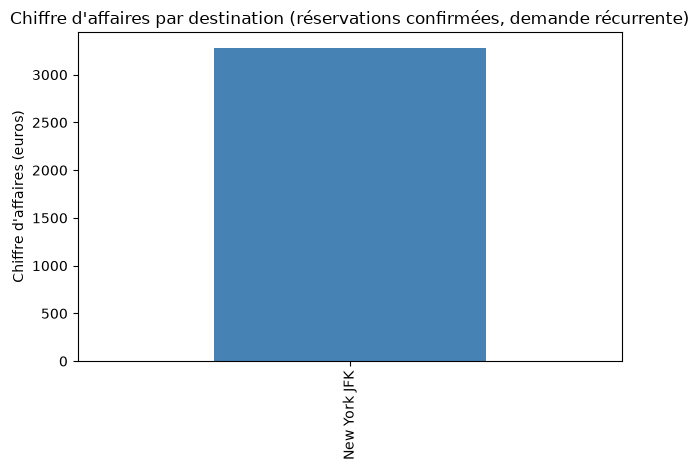

In [26]:
import matplotlib.pyplot as plt

result = query("""

-- ### START CODE HERE ###
SELECT 
    f.destination AS destination,
    SUM(f.price_eur) AS total_revenue
FROM bookings b
JOIN flights f ON b.flight_id = f.id
GROUP BY f.destination
HAVING COUNT(b.id) >= 5  -- Ajuste ce chiffre selon le critère exact de "demande récurrente" de ton étape 3
ORDER BY total_revenue DESC;
-- ### END CODE HERE ###

""")
display(result)

assert result.iloc[0]['destination'] == 'New York JFK', \
    f"La destination en tête devrait être New York JFK, tu as {result.iloc[0]['destination']}"

result.plot(kind='bar', x='destination', y='total_revenue', legend=False, color='steelblue')
plt.title("Chiffre d'affaires par destination (réservations confirmées, demande récurrente)")
plt.ylabel("Chiffre d'affaires (euros)")
plt.xlabel("")
plt.tight_layout()
plt.show()

Le graphique parle de lui-même, tu peux rendre ton rapport au directeur.

**Recommandation : renforcer la ligne Nice - New York JFK.** C'est de loin la destination qui génère le plus de chiffre d'affaires, avec une demande récurrente (plusieurs réservations confirmées, étape 3), une clientèle premium qui voyage en business et en first (étape 4) et qui accepte des prix bien au-dessus du marché (étape 6). Pour remplir le nouveau vol dès son lancement, le marketing contactera en priorité les grands voyageurs (étape 7) et relancera les clients enregistrés qui n'ont jamais réservé (étape 5).

Une étude complète, menée du début à la fin avec du SQL.

---

## Bilan

Ça y est, on appelle ton vol pour Athènes, tu peux ranger l'ordinateur. En partant d'une vraie question business et en la découpant en étapes, tu as utilisé toutes les briques du SQL du quotidien : SELECT et WHERE pour explorer, GROUP BY et les agrégations pour compter et sommer, les jointures pour croiser les tables, les sous-requêtes pour comparer au marché. C'est exactement comme ça que travaille un analyste : une question, un cheminement, une recommandation.

Allez ! Il est maintenant temps que les vacances démarrent !

Rendez-vous dimanche prochain pour le deuxième projet. Bonnes vacances !